<a href="https://colab.research.google.com/github/akuntugasrapon/RafkiAhmadPagamanda_2311533016_ML2526/blob/main/Praktikum2/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Load Dataset

In [4]:
dataset_url = "https://raw.githubusercontent.com/akuntugasrapon/RafkiAhmadPagamanda_2311533016_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv"

data = pd.read_csv(dataset_url)

data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


Melihat Informasi Dataset

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


Visualisasi Target

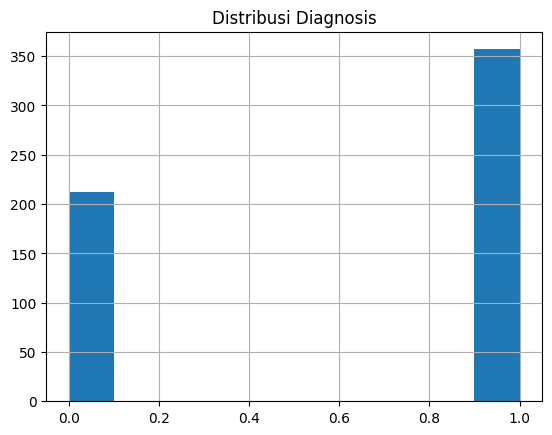

In [6]:
data["diagnosis"].hist()

plt.title("Distribusi Diagnosis")
plt.show()

Heatmap Korelasi

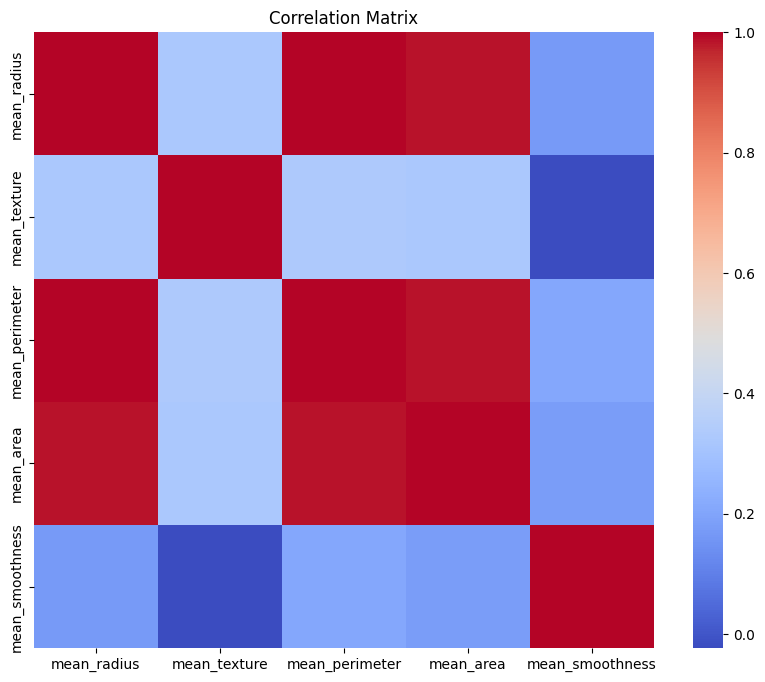

In [7]:
corr = data.iloc[:,:-1].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

Pisahkan Feature dan Target

In [8]:
X = data.drop(columns="diagnosis")
y = data["diagnosis"]

Split Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=41
)

Standardisasi Data

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Membuat Model Gaussian Naive Bayes

In [11]:
model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

Prediksi Model

In [12]:
y_pred = model.predict(X_test)

Evaluasi Model

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.9473684210526315
Precision : 0.9473684210526315
Recall : 0.972972972972973
F1 Score : 0.96


Confusion Matrix

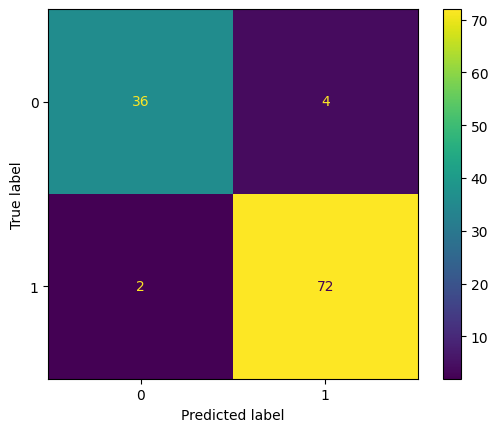

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()